In [1]:
# Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from numpy.random import poisson
from matplotlib.path import Path


from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline

/home/joao/Documents/Research/4_sys_analysis
Working Directory has been set to `/home/joao/Documents/Research/4_sys_analysis`


2021-09-14 22:02:03,462 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2021-09-14 22:02:10,710 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autoarray/config
2021-09-14 22:02:11,599 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2021-09-14 22:02:11,848 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


In [2]:
#N_iter=10000
grid_scale = 0.1

In [3]:
def rotate_matrix(m):
    return [[m[j][i] for j in range(len(m))] for i in range(len(m[0])-1,-1,-1)]

In [53]:
def prepare_data(path, img_name, psf_name, out_name, ori_image):
    """
    path: str path of imgblocks
    img_name: fits image name
    psf_name: fits psf name
    """
    
    width = 150
    height = 150
    # read an image from fits
    image = al.Array2D.from_fits(file_path=path+img_name,
                                 pixel_scales=grid_scale,
                                 hdu=0) # hdu from 0
    original_image = al.Array2D.from_fits(file_path=path+ori_image,
                                          pixel_scales=grid_scale,
                                          hdu=0) # hdu from 0
    
    """
    # noise map
    #noise_image = np.ones(len(image))*0.1 # filled with 0.5
    #noise_map = al.Array2D.manual_slim(noise_image, pixel_scales=grid_scale, shape_native=image.shape_native)
    """

    
    noise_image = []
    for i in range(0, len(image)):
            noise_image.append(np.std([image[i], original_image[i]]))
        
    noise_image = np.array(noise_image)
    noise_map = al.Array2D.manual_slim(noise_image, pixel_scales=grid_scale, shape_native=image.shape_native)
    
    # psf
    psf = al.Kernel2D.from_fits(file_path=path+psf_name,
                                hdu=0,
                                pixel_scales=grid_scale)
    # reescale the psf
    new_psf=psf.rescaled_with_odd_dimensions_from_rescale_factor(rescale_factor=1)
    # image object
    imaging = al.Imaging(image=image, psf=new_psf, noise_map=noise_map)
    
    # text file containing polyhon vertices
    file = open(path+out_name)
    lines = file.readlines()
    file.close()

    polygon=[]
    for i in range(0, len(lines)):
        # if the line starts with polyhon select the vertices in the format (a,b,c, etc)
        if lines[i].startswith("polygon"):
            # format ending with: # color=red width=3
            # if you not changing any color or width change the number X: [8:-X]
            polygon.append(np.array(lines[i][8:-22].split(",")).astype(np.float))

    # reshape to get 2 columns as vertices
    for i in range(0, len(polygon)):
        polygon[i] = polygon[i].reshape(int(len(polygon[i])/2),2)

    # transform into tuples (a, b)
    for i in range(0, len(polygon)):
        for j in range(0, len(polygon[i])):
            polygon[i][j] = tuple(polygon[i][j])

    # to construct the final mask
    final_mask=np.zeros(22500).reshape(150,150) # zero array with shape (150, 150)
    for i in range(0, len(polygon)):
        poly_path=Path(polygon[i])

        # algoritm to build the mask
        x, y = np.mgrid[:height, :width]
        coors=np.hstack((x.reshape(-1, 1), y.reshape(-1,1))) # coors.shape is (4000000,2)
        # rotate the mask because the image is rotated in pyautolens (or matrix)
        mask = poly_path.contains_points(coors)
        new_mask=rotate_matrix(mask.reshape(150, 150))
        final_mask = final_mask+new_mask
    # change zeros to 1 and 1 to zeros
    mask=al.Mask2D.manual(1-final_mask, pixel_scales=imaging.pixel_scales)
    #if mask_circular:
        #mask = al.Mask2D.circular(shape_native=imaging.shape_native,
                                  #pixel_scales=imaging.pixel_scales,
                                  #radius=radius)
                
    imaging = imaging.apply_mask(mask=mask)
    return imaging

In [5]:
def prepare_model(lens_redshift, source_redshift=1., dm_imput=False):
    """
    source_redshift: float source redshift value
    lens_redshift: float lens redshift value
    dm_imput: boolean parameter for dark matter modelization
    """
    # source galaxy model
    source_galaxy_model = af.Model(al.Galaxy,
                               redshift=source_redshift,
                               disk=al.lp.EllExponential)
    
    if dm_imput:
        dark = af.Model(al.mp.EllNFW)
        bulge = af.Model(al.lp.EllDevVaucouleurs)
        bulge.centre = dark.centre
        # lens galaxy model
        lens_galaxy_model = af.Model(al.Galaxy,
                                 redshift=lens_redshift,
                                 bulge=bulge,
                                 mass=al.mp.EllIsothermal,
                                 dark=dark)
    else:
        bulge = af.Model(al.lp.EllDevVaucouleurs)
        lens_galaxy_model = af.Model(al.Galaxy,
                                 redshift=lens_redshift,
                                 bulge=bulge,
                                 mass=al.mp.EllIsothermal)
    
    
    return af.Collection(galaxies=af.Collection(lens=lens_galaxy_model, source=source_galaxy_model))


## CS82SL013639.16+000818.38

In [22]:
from IPython.display import Image

### 1st step

Contours:

* Level: 6
* Smoothness: 7
* low: -0.395281
* high: 0.744661

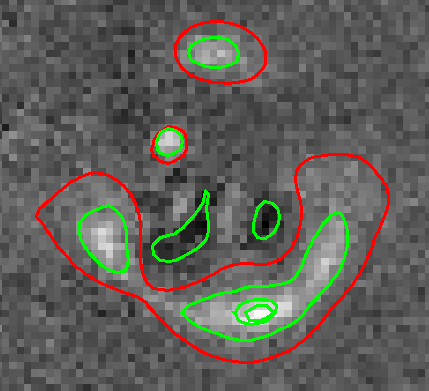

In [49]:
imgblocks_paths = "./imgblocks/sys_1/" # imgblocks path
img_name = "resid.fits" # specific imgblock
psf_img_name = "psf2.fits" # psf
reg_contours = "sys_1_step1.reg"
ori_image = "CS82SL013639.16+000818.38.fits"

In [50]:
img_1 = prepare_data(imgblocks_paths, img_name, psf_img_name, reg_contours, ori_image)

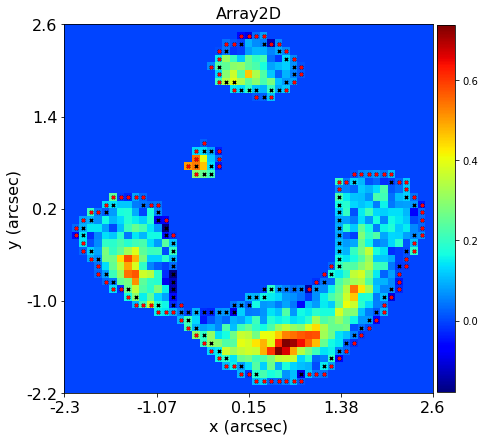

In [54]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_1.image)
array_plotter.figure_2d()

In [58]:
model = prepare_model(0.344)

In [59]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_1_dist_step1",
    unique_tag="sys_1_dist_step1",
    nlive=150,
    number_of_cores=6,
)
analysis = al.AnalysisImaging(dataset=img_1)

result = search.fit(model=model, analysis=analysis)

2021-09-14 22:31:20,714 - sys_1_dist_step1 - INFO - Creating search
2021-09-14 22:31:20,715 - sys_1_dist_step1 - INFO - Starting search
2021-09-14 22:31:20,718 - sys_1_dist_step1 - INFO - Saving path info
2021-09-14 22:31:20,765 - sys_1_dist_step1 - INFO - Not complete. Starting non-linear search.
2021-09-14 22:31:20,766 - sys_1_dist_step1 - INFO - number_of_cores == 6...
2021-09-14 22:31:20,767 - sys_1_dist_step1 - WARNING - ...using SneakyPool. This copies the likelihood functionto each process on instantiation to avoid copying multipletimes.
2021-09-14 22:31:20,768 - process 0 - INFO - created
2021-09-14 22:31:20,769 - process 1 - INFO - created
2021-09-14 22:31:20,769 - process 2 - INFO - created
2021-09-14 22:31:20,770 - process 3 - INFO - created
2021-09-14 22:31:20,771 - process 4 - INFO - created
2021-09-14 22:31:20,772 - process 5 - INFO - created
2021-09-14 22:31:20,838 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior l

/home/joao/.local/lib/python3.8/site-packages/dynesty/dynesty.py:373: UserWarning: A note of caution: having `nlive < ndim * (ndim + 1) // 2` may result in unconstrained bounding distributions.
  warnings.warn("A note of caution: "
494it [00:35,  2.55it/s, bound: 0 | nc: 103 | ncall: 4980 | eff(%):  9.920 | loglstar:   -inf < 100.308 <    inf | logz: 92.810 +/-    nan | dlogz: 77.864 >  0.159]           /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generat

2021-09-14 22:31:59,495 - sys_1_dist_step1 - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).


1001it [00:35, 13.15it/s, bound: 41 | nc: 5 | ncall: 9712 | eff(%): 10.307 | loglstar:   -inf < 174.031 <    inf | logz: 165.695 +/-    nan | dlogz: 15.812 >  0.159]/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:238: UserWarning: Random walk proposals appear to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random walk proposals appear to be "
1012it [00:42, 24.08it/s, +150 | bound: 42 | nc: 1 | ncall: 10232 | eff(%): 11.357 | loglstar:   -inf < 188.116 <    inf | logz: 176.919 +/-    nan | dlogz:  0.457 >  0.159]


2021-09-14 22:32:55,110 - sys_1_dist_step1 - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


...

2021-09-14 22:40:01,446 - sys_1_dist_step1 - INFO - 55000 Iterations: Performing update (Visualization, outputting samples, etc.).


7102it [00:00, 30755.71it/s, +150 | bound: 402 | nc: 1 | ncall: 55540 | eff(%): 13.057 | loglstar:   -inf < 260.344 <    inf | logz: 214.974 +/-    nan | dlogz:  0.001 >  0.159]


2021-09-14 22:40:18,330 - sys_1_dist_step1 - INFO - 60000 Iterations: Performing update (Visualization, outputting samples, etc.).


7102it [00:00, 1450593.96it/s, +150 | bound: 402 | nc: 1 | ncall: 55540 | eff(%): 13.057 | loglstar:   -inf < 260.344 <    inf | logz: 214.974 +/-    nan | dlogz:  0.001 >  0.159]


2021-09-14 22:40:34,884 - sys_1_dist_step1 - INFO - 65000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-14 22:40:48,571 - sys_1_dist_step1 - INFO - 70000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-14 22:41:36,546 - sys_1_dist_step1 - INFO - Removing zip file


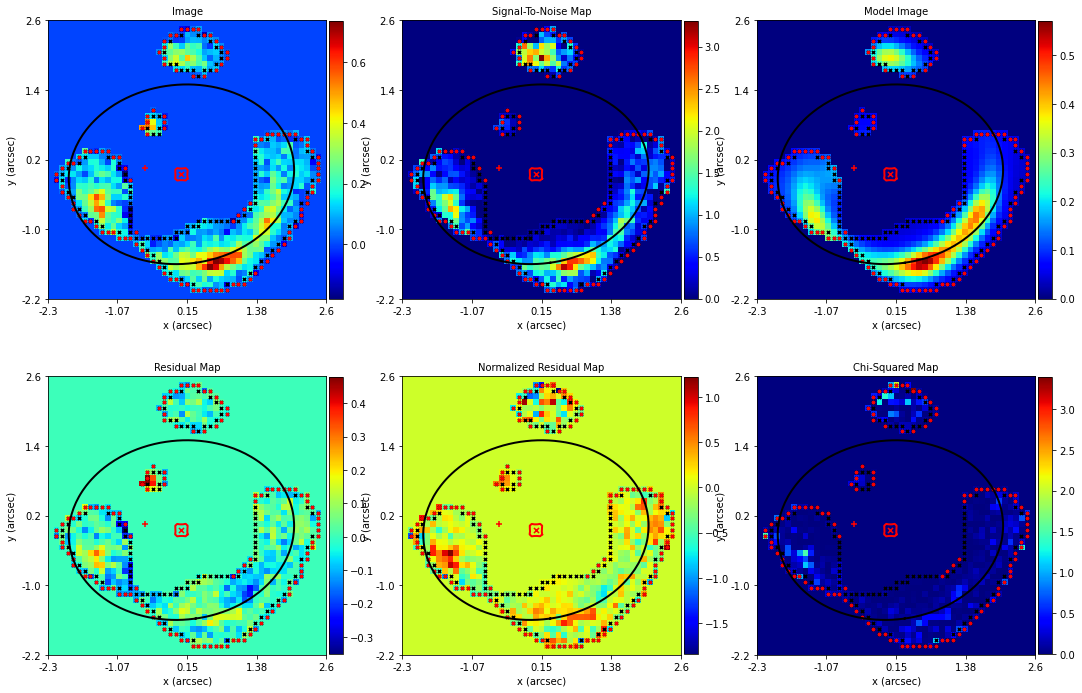

In [60]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

Contours

* Level: 6
* Smoothness: 7
* low: -0.395281
* high: 0.744661

In [64]:
imgblocks_paths = "./imgblocks/sys_1/" # imgblocks path
img_name = "resid.fits" # specific imgblock
psf_img_name = "psf2.fits" # psf
reg_contours = "sys_1_step2.reg"
ori_image = "CS82SL013639.16+000818.38.fits"

In [65]:
img_1 = prepare_data(imgblocks_paths, img_name, psf_img_name, reg_contours, ori_image)

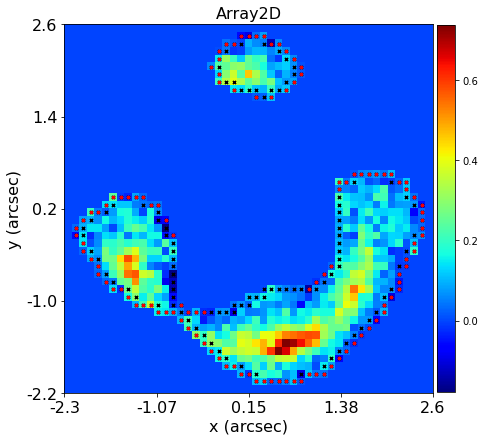

In [66]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_1.image)
array_plotter.figure_2d()

In [67]:
model = prepare_model(0.344)

In [72]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_1_dist_step2",
    unique_tag="sys_1_dist_step2",
    nlive=100,
    number_of_cores=6,
)
analysis = al.AnalysisImaging(dataset=img_1)

result = search.fit(model=model, analysis=analysis)

2021-09-14 22:57:19,089 - sys_1_dist_step2 - INFO - Creating search
2021-09-14 22:57:19,096 - sys_1_dist_step2 - INFO - Starting search
2021-09-14 22:57:19,098 - sys_1_dist_step2 - INFO - Saving path info
2021-09-14 22:57:19,138 - sys_1_dist_step2 - INFO - Not complete. Starting non-linear search.
2021-09-14 22:57:19,138 - sys_1_dist_step2 - INFO - number_of_cores == 6...
2021-09-14 22:57:19,139 - sys_1_dist_step2 - WARNING - ...using SneakyPool. This copies the likelihood functionto each process on instantiation to avoid copying multipletimes.
2021-09-14 22:57:19,140 - process 0 - INFO - created
2021-09-14 22:57:19,141 - process 1 - INFO - created
2021-09-14 22:57:19,141 - process 2 - INFO - created
2021-09-14 22:57:19,142 - process 3 - INFO - created
2021-09-14 22:57:19,143 - process 4 - INFO - created
2021-09-14 22:57:19,144 - process 5 - INFO - created
2021-09-14 22:57:19,288 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior l

/home/joao/.local/lib/python3.8/site-packages/dynesty/dynesty.py:373: UserWarning: A note of caution: having `nlive < ndim * (ndim + 1) // 2` may result in unconstrained bounding distributions.
  warnings.warn("A note of caution: "
340it [00:28,  2.32it/s, bound: 0 | nc: 59 | ncall: 3433 | eff(%):  9.904 | loglstar:   -inf < 107.186 <    inf | logz: 99.670 +/-  1.253 | dlogz: 93.788 >  0.109]           /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generati

2021-09-14 22:57:59,113 - sys_1_dist_step2 - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).



1052it [00:31, 33.45it/s, +100 | bound: 82 | nc: 1 | ncall: 10150 | eff(%): 11.350 | loglstar:   -inf < 205.095 <    inf | logz: 189.786 +/-  2.554 | dlogz:  0.813 >  0.109]


2021-09-14 22:58:40,304 - sys_1_dist_step2 - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


...

2021-09-14 23:03:00,382 - sys_1_dist_step2 - INFO - 40000 Iterations: Performing update (Visualization, outputting samples, etc.).


5060it [00:03, 1450.54it/s, +100 | bound: 448 | nc: 1 | ncall: 40690 | eff(%): 12.681 | loglstar:   -inf < 272.605 <    inf | logz: 224.445 +/-  1.506 | dlogz:  0.001 >  0.109]


2021-09-14 23:03:21,718 - sys_1_dist_step2 - INFO - 45000 Iterations: Performing update (Visualization, outputting samples, etc.).


5060it [00:00, 1389952.08it/s, +100 | bound: 448 | nc: 1 | ncall: 40690 | eff(%): 12.681 | loglstar:   -inf < 272.605 <    inf | logz: 224.445 +/-  1.506 | dlogz:  0.001 >  0.109]


2021-09-14 23:03:41,432 - sys_1_dist_step2 - INFO - 50000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-14 23:03:57,838 - sys_1_dist_step2 - INFO - 55000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-14 23:04:45,080 - sys_1_dist_step2 - INFO - Removing zip file


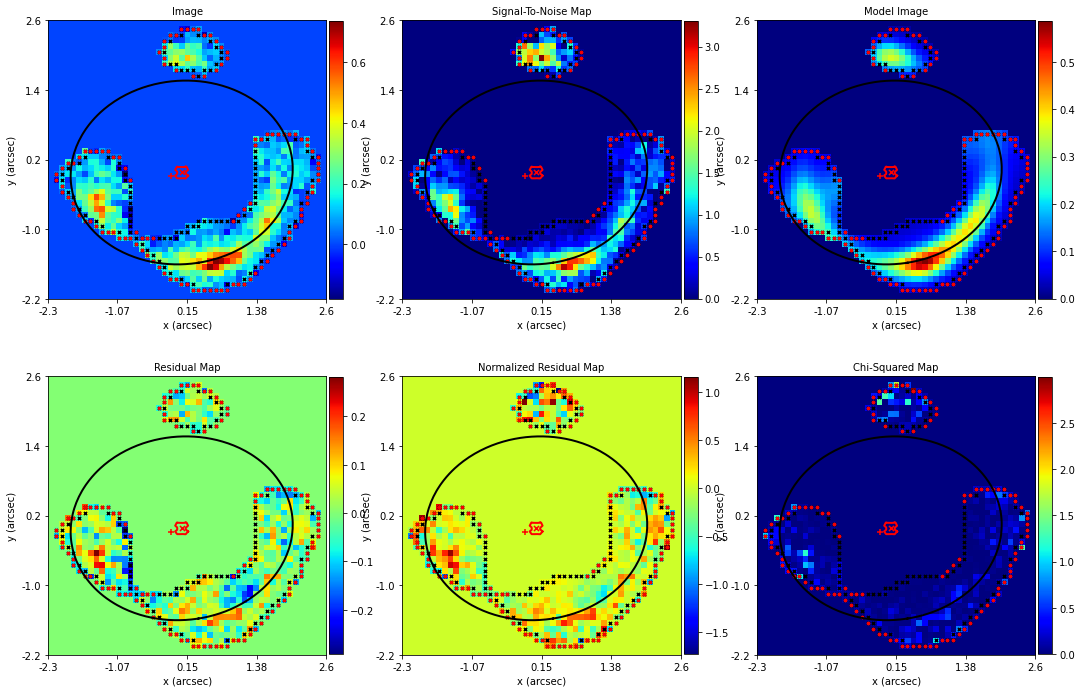

In [73]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

In [12]:
#dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
#dynesty_plotter.cornerplot()

## CS82SL015824.81-003959.60

In [13]:
imgblocks_paths = "./imgblocks/sys_2/" # imgblocks path
img_name = "resid.fits" # specific imgblock
psf_img_name = "psf2.fits" # psf
reg_contours = "sys_2.reg"
ori_image = "CS82SL015824.81-003959.60.fits"

In [14]:
img_2 = prepare_data(imgblocks_paths, img_name, psf_img_name, reg_contours, ori_image)

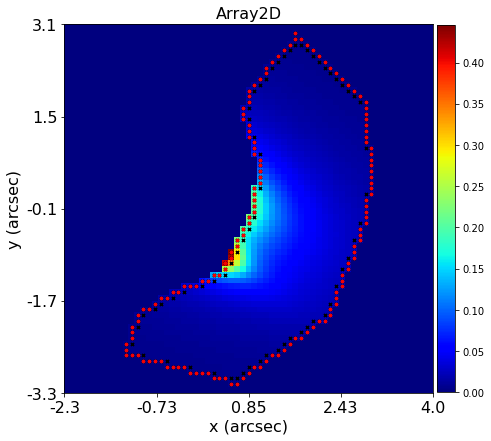

In [15]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_2.noise_map)
array_plotter.figure_2d()

In [16]:
model = prepare_model(0.53)

In [17]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_2_dist",
    unique_tag="sys_2_dist",
    nlive=150,
    number_of_cores=6,
)
analysis = al.AnalysisImaging(dataset=img_2)

result = search.fit(model=model, analysis=analysis)

2021-09-13 17:19:18,612 - sys_2_dist - INFO - Creating search
2021-09-13 17:19:18,614 - sys_2_dist - INFO - Starting search
2021-09-13 17:19:19,423 - sys_2_dist - INFO - Already completed, skipping non-linear search.
2021-09-13 17:19:19,484 - sys_2_dist - INFO - Removing zip file


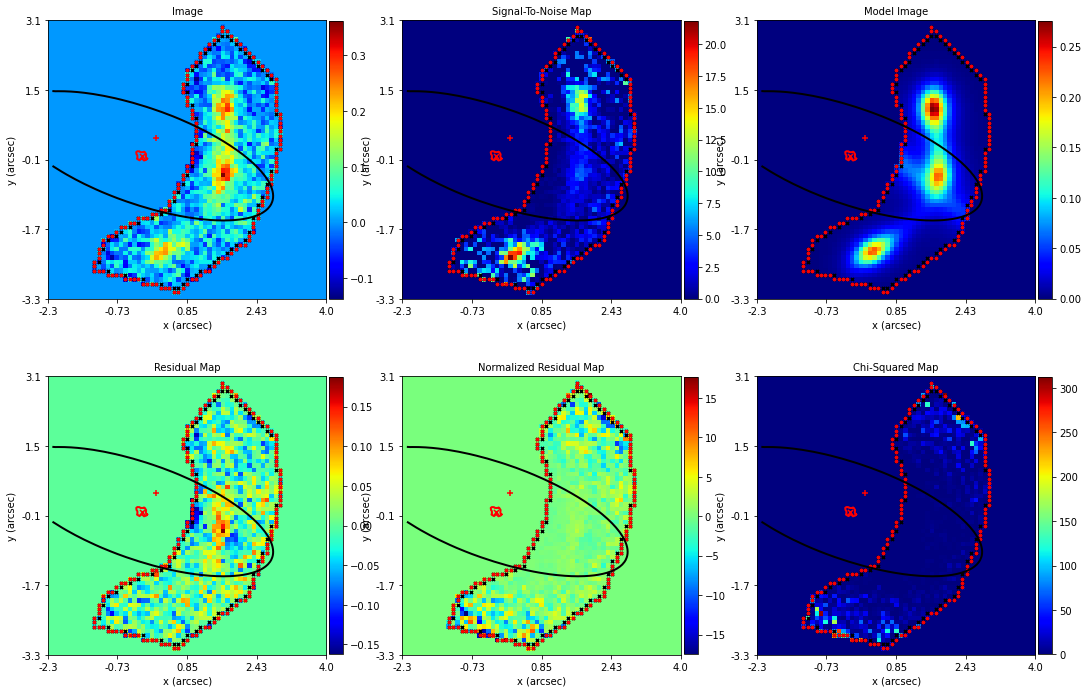

In [18]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

In [19]:
#dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
#dynesty_plotter.cornerplot()

## CS82SL211527.25-003817.26

In [20]:
imgblocks_paths = "./imgblocks/sys_3/" # imgblocks path
img_name = "resid.fits" # specific imgblock
psf_img_name = "psf2.fits" # psf
reg_contours = "sys_3.reg"
ori_image = "CS82SL211527.25-003817.26.fits"

In [21]:
img_3 = prepare_data(imgblocks_paths, img_name, psf_img_name, reg_contours, ori_image)

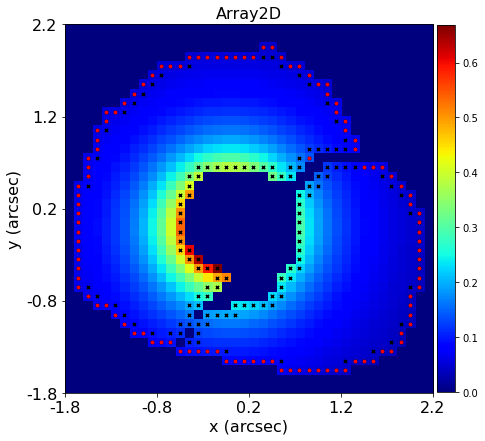

In [22]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_3.noise_map)
array_plotter.figure_2d()

In [23]:
model = prepare_model(0.59)

In [24]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_3_dist",
    unique_tag="sys_3_dist",
    nlive=150,
    number_of_cores=6,
)
analysis = al.AnalysisImaging(dataset=img_3)

result = search.fit(model=model, analysis=analysis)

2021-09-13 17:19:27,094 - sys_3_dist - INFO - Creating search
2021-09-13 17:19:27,095 - sys_3_dist - INFO - Starting search
2021-09-13 17:19:27,572 - sys_3_dist - INFO - Already completed, skipping non-linear search.
2021-09-13 17:19:27,611 - sys_3_dist - INFO - Removing zip file


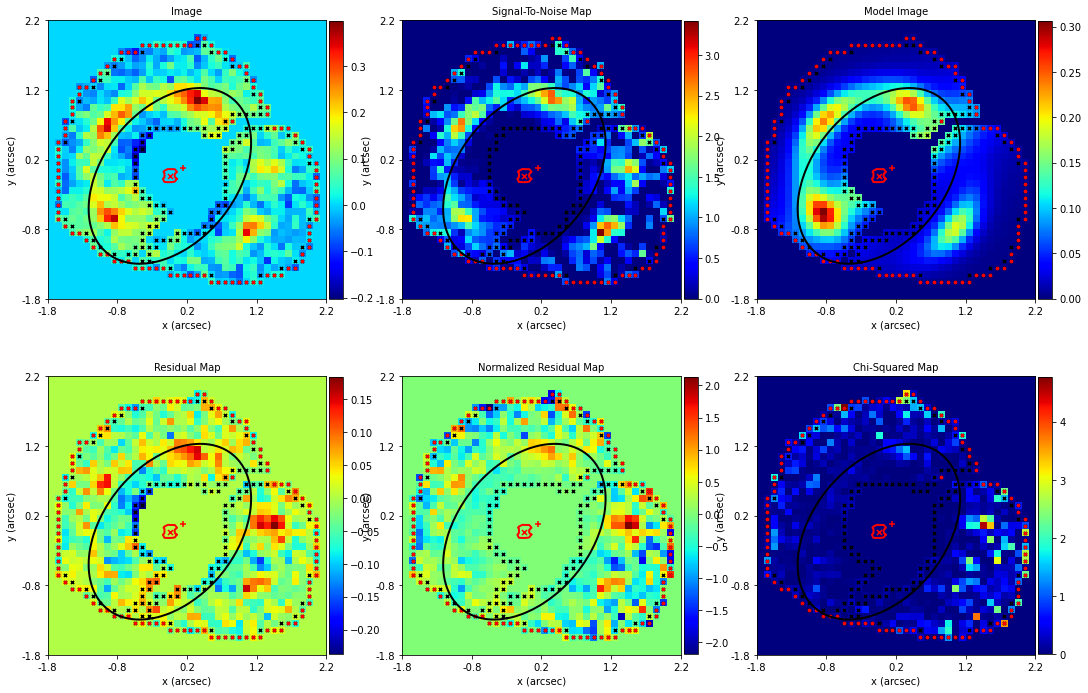

In [25]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

## CS82SL230521.68-000211.52

### 1 case

In [26]:
imgblocks_paths = "./imgblocks/sys_4/" # imgblocks path
img_name = "resid.fits" # specific imgblock
psf_img_name = "psf2.fits" # psf
reg_contours = "sys_4_2.reg"
ori_image = "CS82SL230521.68-000211.52.fits"

In [27]:
img_4 = prepare_data(imgblocks_paths, img_name, psf_img_name, reg_contours, ori_image)

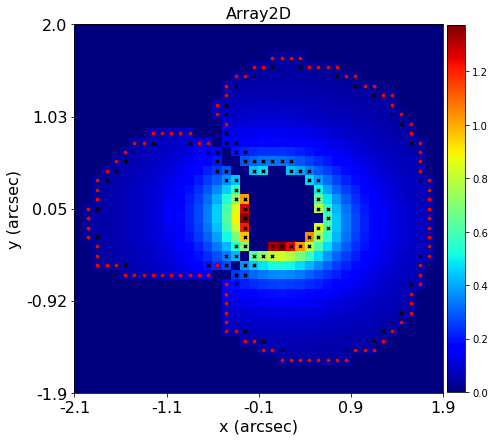

In [28]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_4.noise_map)
array_plotter.figure_2d()

In [32]:
model = prepare_model(0.53)

In [33]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_4_dist",
    unique_tag="sys_4_dist",
    nlive=150,
    number_of_cores=6,
)
analysis = al.AnalysisImaging(dataset=img_4)

result = search.fit(model=model, analysis=analysis)

2021-09-13 17:27:36,240 - sys_4_dist - INFO - Creating search
2021-09-13 17:27:36,243 - sys_4_dist - INFO - Starting search
2021-09-13 17:27:36,245 - sys_4_dist - INFO - Saving path info
2021-09-13 17:27:36,280 - sys_4_dist - INFO - Not complete. Starting non-linear search.
2021-09-13 17:27:36,281 - sys_4_dist - INFO - number_of_cores == 6...
2021-09-13 17:27:36,282 - sys_4_dist - WARNING - ...using SneakyPool. This copies the likelihood functionto each process on instantiation to avoid copying multipletimes.
2021-09-13 17:27:36,283 - process 0 - INFO - created
2021-09-13 17:27:36,284 - process 1 - INFO - created
2021-09-13 17:27:36,285 - process 2 - INFO - created
2021-09-13 17:27:36,287 - process 3 - INFO - created
2021-09-13 17:27:36,288 - process 4 - INFO - created
2021-09-13 17:27:36,289 - process 5 - INFO - created
2021-09-13 17:27:36,432 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior limits and other constraints.
2021-09

/home/joao/.local/lib/python3.8/site-packages/dynesty/dynesty.py:373: UserWarning: A note of caution: having `nlive < ndim * (ndim + 1) // 2` may result in unconstrained bounding distributions.
  warnings.warn("A note of caution: "
551it [00:37, 14.71it/s, +150 | bound: 0 | nc: 1 | ncall: 5156 | eff(%): 13.596 | loglstar:   -inf < 189.113 <    inf | logz: 180.530 +/-    nan | dlogz:  0.646 >  0.159]      

2021-09-13 17:28:15,398 - sys_4_dist - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).



552it [00:00, 3746.36it/s, bound: 0 | nc: 24 | ncall: 5180 | eff(%): 10.656 | loglstar:   -inf < 155.142 <    inf | logz: 150.162 +/-    nan | dlogz: 35.314 >  0.159]/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number gen

2021-09-13 17:29:03,473 - sys_4_dist - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


...

2021-09-13 17:42:37,201 - sys_4_dist - INFO - 90000 Iterations: Performing update (Visualization, outputting samples, etc.).


11410it [00:21, 539.31it/s, +150 | bound: 692 | nc: 1 | ncall: 94186 | eff(%): 12.274 | loglstar:   -inf < 673.720 <    inf | logz: 599.726 +/-    nan | dlogz:  0.001 >  0.159]


2021-09-13 17:43:31,818 - sys_4_dist - INFO - 95000 Iterations: Performing update (Visualization, outputting samples, etc.).


11410it [00:00, 2322366.61it/s, +150 | bound: 692 | nc: 1 | ncall: 94186 | eff(%): 12.274 | loglstar:   -inf < 673.720 <    inf | logz: 599.726 +/-    nan | dlogz:  0.001 >  0.159]


2021-09-13 17:44:06,293 - sys_4_dist - INFO - 100000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-13 17:44:29,695 - sys_4_dist - INFO - 105000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-13 17:45:48,542 - sys_4_dist - INFO - Removing zip file


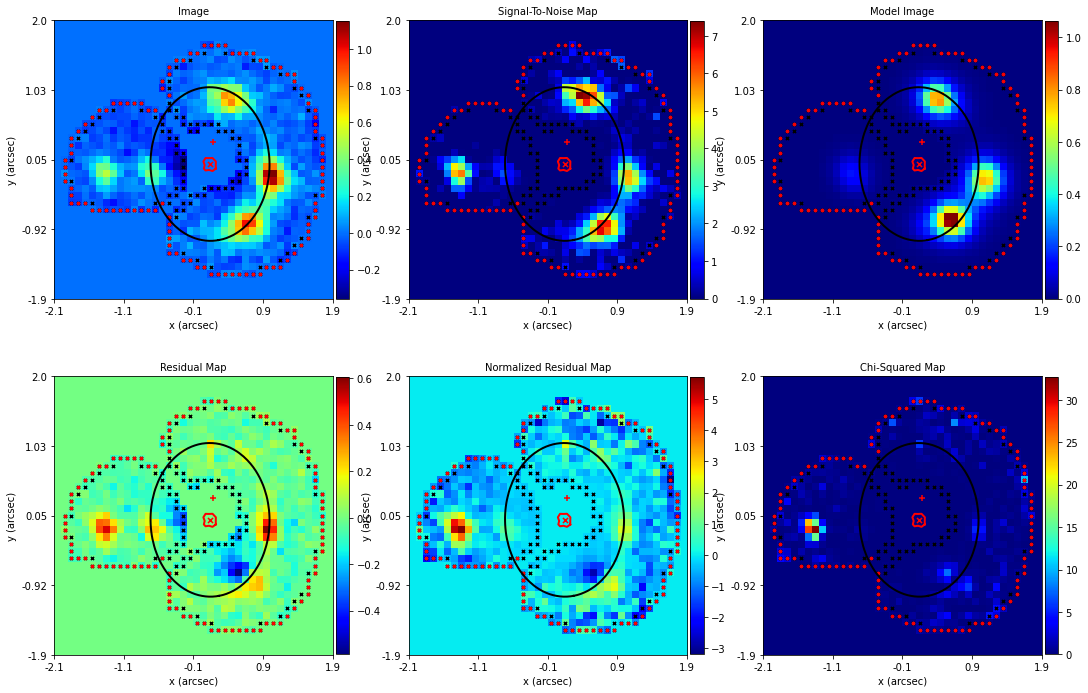

In [34]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()